# United States Crime Analysis (1979–2023)

This dataset and report present a comprehensive view of U.S. crime from 1979 to 2023, based on *FBI Summary Reporting System (SRS)* data. It analyzes national and state-level trends, per-capita patterns, and the divide between property and violent crimes. The goal is to predict aggravated assault rate per capita to capture how crime evolves over time while accounting for different US states.

<br></br>

Despite various implemented mechanisms to prevent crime, it remains a major issue to deal with in everyday life. Very often defined as a socially harmful act,  . The goal is to predict the assault rate based on its past assault, state location, and number of years, using the eXtreme Boosting as the preferred method. Eventually, additional analysis on crime beharior can help agencies predict which states in the USA might be more influenced by an increase of aggravated assault rate.

<br></br>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import gdown
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

In [2]:
# Load dataset on google drive
file_id = "1QdvsX79iMvKlIihp0vnVAH5qQEQxRWY3"
url = f"https://drive.google.com/uc?export=download&id={file_id}"

gdown.download(url, "estimated_crimes_1979_2023_cleaned_csv.csv", quiet=True)
df = pd.read_csv("estimated_crimes_1979_2023_cleaned_csv.csv")

# Show 5 rows
df.head()

,year,state_abbr,state_name,population,violent_crime,property_crime,total_crime,homicide,rape_legacy,rape_legacy_cleaned,...,rape_revised,rape_revised_cleaned,burglary,larceny,motor_vehicle_theft,violent_crime_rate_100k,%violent_crime_100k,property_crime_rate_100k,%property_crime_100k,%total_crime_per_100k
0,2012,WY,Wyoming,576626,1161,13222,14383,14,154.0,154,...,NaN,0,2125,10513,584,201.343679,0.201344,2292.994072,2.292994,2.494338
1,2012,WV,West Virginia,1856680,5943,44500,50443,70,415.0,415,...,NaN,0,11466,30800,2234,320.087468,0.320087,2396.751190,2.396751,2.716839
2,2012,WI,Wisconsin,5724554,16254,140780,157034,169,1228.0,1228,...,NaN,0,27931,104619,8230,283.934783,0.283935,2459.230885,2.459231,2.743166
3,2012,WA,Washington,6895318,20553,254377,274930,217,2250.0,2250,...,NaN,0,61376,166338,26663,298.071822,0.298072,3689.126448,3.689126,3.987198
4,2012,VT,Vermont,625953,891,15653,16544,8,131.0,131,...,NaN,0,4179,11014,460,142.342955,0.142343,2500.666983,2.500667,2.643010


In [3]:
# Dataset size
df.shape

(2295, 22)

In [4]:
# Show data types
df.dtypes

,0
year,int64
state_abbr,object
state_name,object
population,int64
violent_crime,int64
property_crime,int64
total_crime,int64
homicide,int64
rape_legacy,float64
rape_legacy_cleaned,int64


In [5]:
# check for missing values
df.isna().sum()

,0
year,0
state_abbr,0
state_name,0
population,0
violent_crime,0
property_crime,0
total_crime,0
homicide,0
rape_legacy,357
rape_legacy_cleaned,0


The 2 columns with missing values have been cleaned and were renamed `rape_legacy_cleaned	` and `rape_revised_cleaned`. Thus, we should drop the original ones.

In [6]:
# Remove columns
df.drop(columns=["rape_legacy", "rape_revised"], inplace=True)

In [7]:
# c=Check duplicated values
df.duplicated().sum()

np.int64(0)

<br></br>

# **Data Exploration**

In [8]:
# Summary statistics of total crime
df['total_crime'].describe()

,total_crime
count,2.295000e+03
mean,2.265404e+05
std,2.843583e+05
min,8.667000e+03
25%,5.051900e+04
50%,1.474810e+05
75%,2.640925e+05
max,2.061761e+06


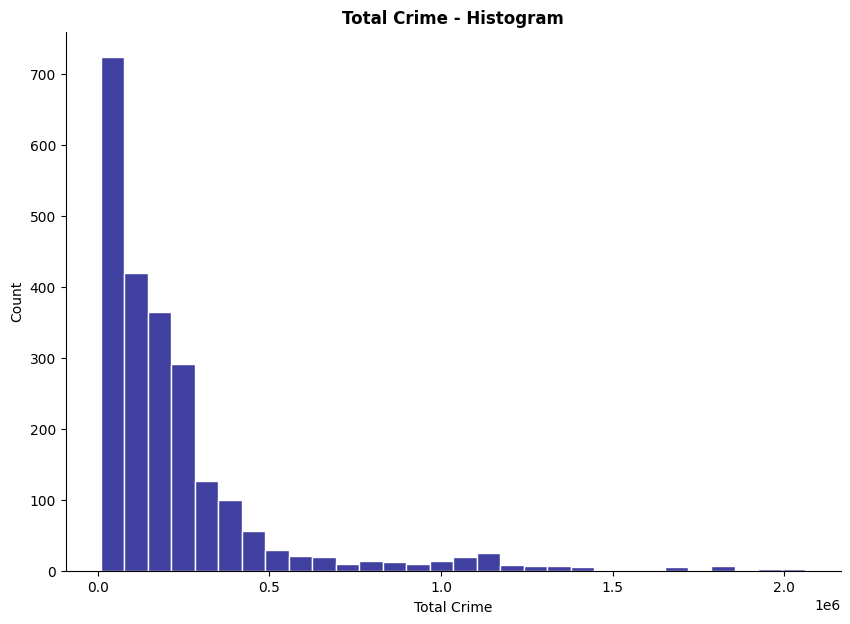

In [9]:
# Plot total crime histogram
plt.figure(figsize=(10,7))
sns.histplot(df['total_crime'], bins =30, color="navy", edgecolor="white")
plt.title("Total Crime - Histogram", fontweight="bold")
plt.xlabel("Total Crime")
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.show()

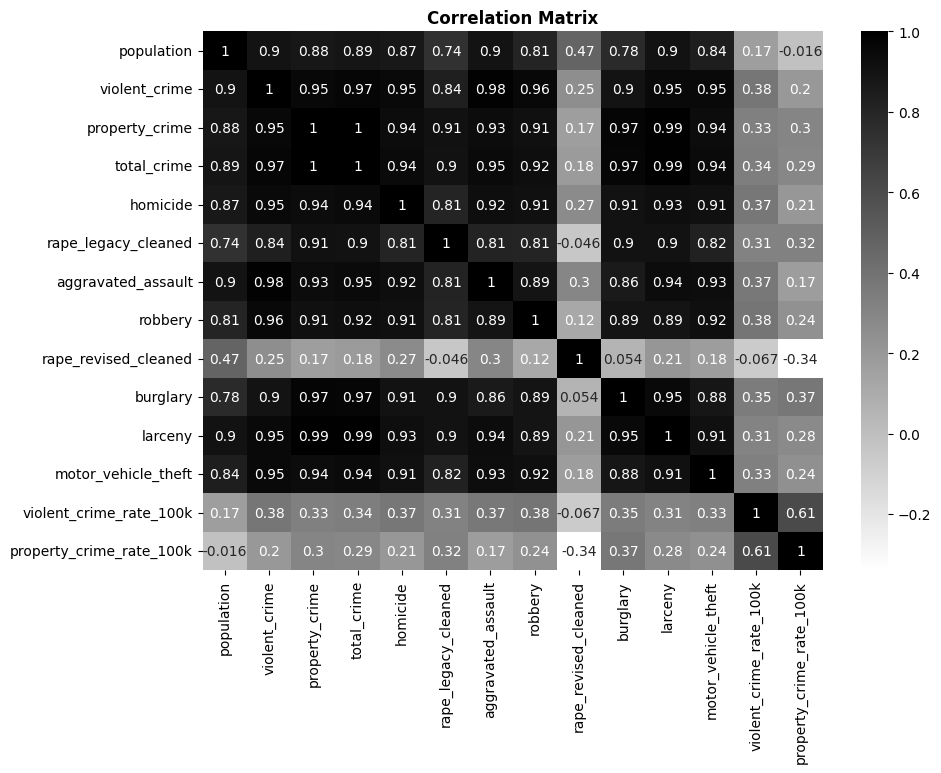

In [56]:
# Plot Coreelation matrix
numerical = ['population',	'violent_crime',	'property_crime',	'total_crime',	'homicide', 'rape_legacy_cleaned',	'aggravated_assault',	'robbery',
             'rape_revised_cleaned', 'burglary',	'larceny',	'motor_vehicle_theft',	'violent_crime_rate_100k', 'property_crime_rate_100k']

correlation_matrix = df[numerical].corr()

plt.figure(figsize=(10,7))
sns.heatmap(correlation_matrix, annot=True, cmap='binary')
plt.title("Correlation Matrix", fontweight="bold")
plt.show()

### Comment:
The correlation matrix reveales strong positive correlations between population and most crime variables, suggesting the presence of multicollinearity among them. Because many of the crime features overlap in terms of information, the model below will favor just a subset of crimes feature to avoid redundant information.

<br></br>

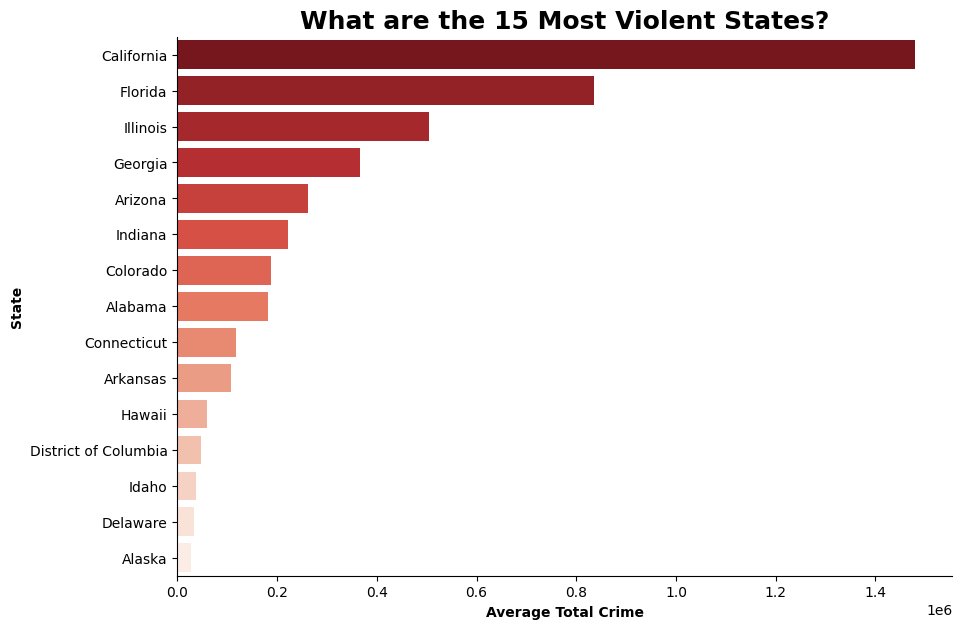

In [10]:
# Create top 15 most violent states object
top_10_state = df.groupby('state_name')['total_crime'].mean().head(15).reset_index()
top_10_state = top_10_state.sort_values(by='total_crime', ascending=False)

# Barplot
plt.figure(figsize=(10,7))
sns.barplot(top_10_state, x='total_crime', y='state_name', palette='Reds_r', hue='state_name', legend=False)
plt.title("What are the 15 Most Violent States?", fontweight='bold', fontsize=18)
plt.xlabel("Average Total Crime", fontweight='bold')
plt.ylabel("State", fontweight='bold')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.show()

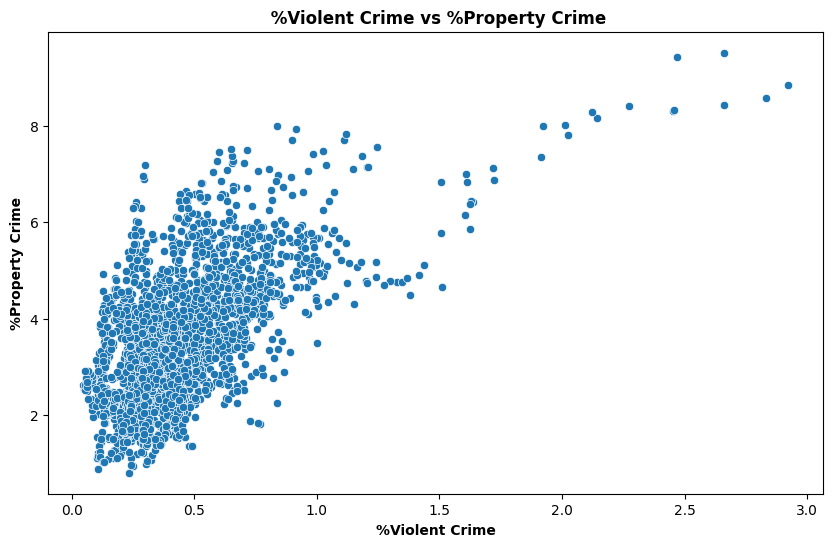

In [11]:
# Scatter plot
plt.figure(figsize=(10,6))
sns.scatterplot(x=df['%violent_crime_100k'], y = df["%property_crime_100k"])
plt.title(" %Violent Crime vs %Property Crime", fontweight="bold")
plt.xlabel("%Violent Crime", fontweight='bold')
plt.ylabel("%Property Crime", fontweight='bold')
plt.show()

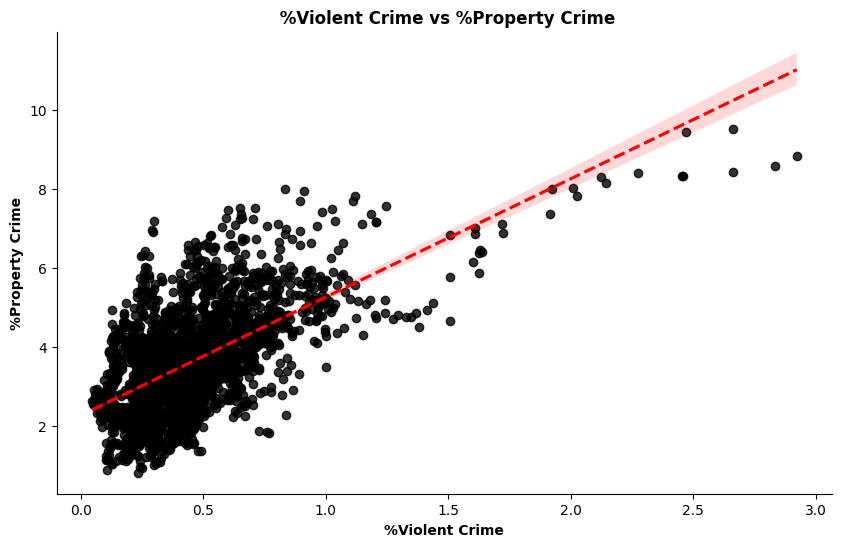

In [12]:
# Scatter plot with trend line
plt.figure(figsize=(10,6))
sns.regplot(x=df['%violent_crime_100k'], y = df["%property_crime_100k"],
            scatter_kws={'color':'black'}, line_kws={'color':'red', 'linestyle':'--'})
plt.title(" %Violent Crime vs %Property Crime", fontweight="bold")
plt.xlabel("%Violent Crime", fontweight='bold')
plt.ylabel("%Property Crime", fontweight='bold')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

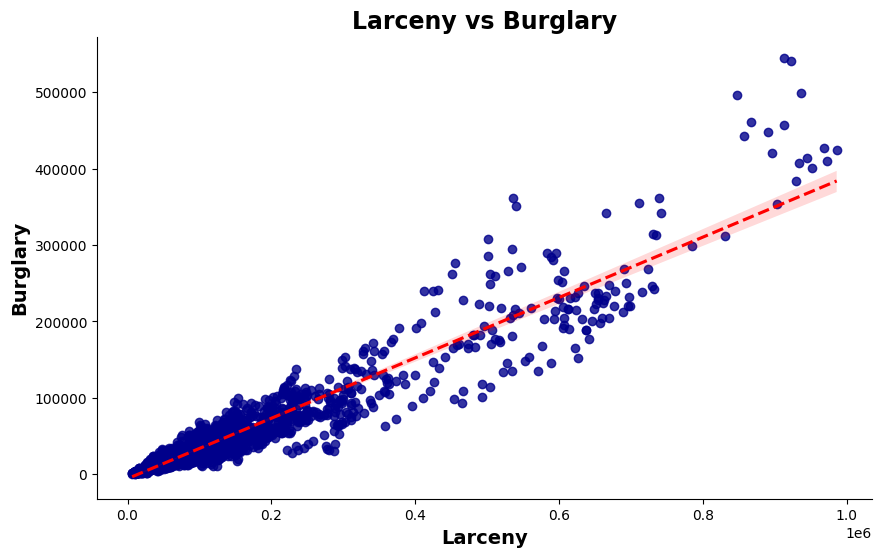

In [13]:
# Scatter plot with regression line burglary vs larceny
plt.figure(figsize=(10,6))
sns.regplot(x=df['larceny'], y = df["burglary"],
            scatter_kws={'color':'darkblue'}, line_kws={'color':'red', 'linestyle':'--'})
plt.title("Larceny vs Burglary", fontweight="bold", fontsize=17)
plt.xlabel("Larceny", fontweight='bold', fontsize=14)
plt.ylabel("Burglary", fontweight='bold', fontsize=14)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

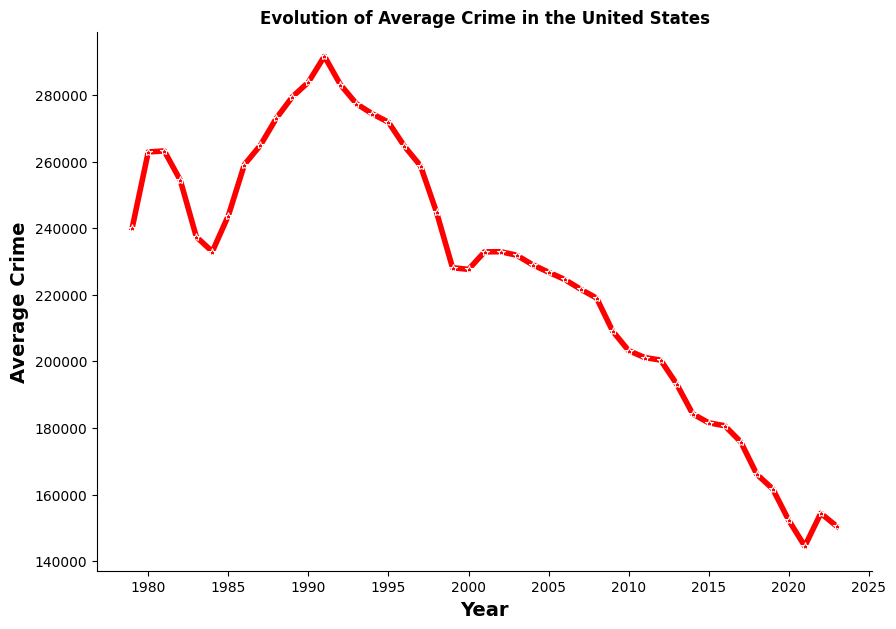

In [14]:
# Convert year column to datetime
df['year'] = pd.to_datetime(df['year'], format='%Y')

# Create line object
line_df = df.groupby('year')['total_crime'].mean().reset_index()

# Plot line
plt.figure(figsize=(10,7))
sns.lineplot(line_df, x='year', y='total_crime', color='red', linewidth=4, marker='*')
plt.title("Evolution of Average Crime in the United States", fontweight='bold')
plt.xlabel("Year", fontweight='bold', fontsize=14)
plt.ylabel("Average Crime", fontweight='bold', fontsize=14)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()



---





# **Model Development**


In [16]:

# Feature engineering lag and assault rate
df['aa_lag1'] = df.groupby('state_name')['aggravated_assault'].shift(1)
df['assault_rate'] = df['aggravated_assault'] / df['population'] *100000

# Change year back to integer for the model
df['year'] = df['year'].astype('int64')

# Set target and predictors
features = ['year' , 'aa_lag1','state_name']
X = df[features]
y = df['assault_rate']

# Encode states
cat_feature = ['state_name']
X_encoded = pd.get_dummies(X, columns= cat_feature, drop_first=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, random_state=42, test_size = 0.2)

# Fit model
model = XGBRegressor(n_estimators=200,
                     learning_rate=0.1,
                     min_child_weight= 5,
                     subsample=0.8,
                     colsample_bytree=0.8,
                     max_depth=4, random_state=42)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Show metrics results
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)**0.5
print("R-square is:", round(r2,3))
print("Root Mean Square Error is:", round(rmse,3))

R-square is: 0.935
Root Mean Square Error is: 36.56


In [29]:
# Create feature importance dataframe to view
importance = model.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': importance
}).sort_values('Importance', ascending=False).head(22)

feat_imp


,Feature,Importance
9,state_name_District of Columbia,0.226334
32,state_name_New Mexico,0.092734
41,state_name_South Carolina,0.071851
2,state_name_Alaska,0.067260
19,state_name_Louisiana,0.043246
10,state_name_Florida,0.036759
36,state_name_Ohio,0.034254
30,state_name_New Hampshire,0.033801
1,aa_lag1,0.032323
8,state_name_Delaware,0.028811


/tmp/ipykernel_16657/3556142337.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x= feat_imp['Importance'], y= feat_imp['Feature'], palette='Blues_r')


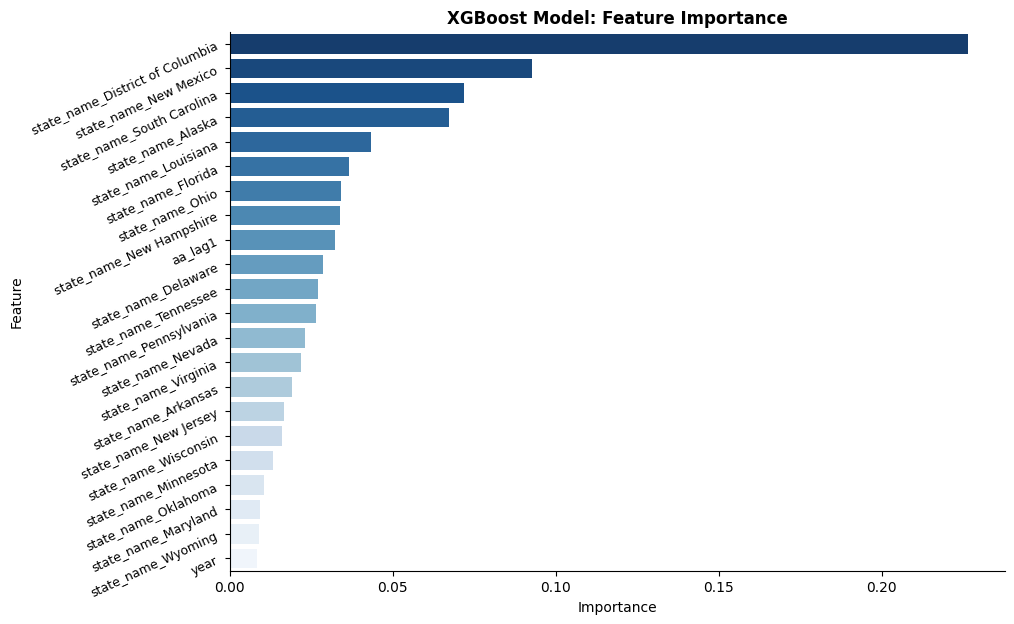

In [44]:
# Plot feature importance
plt.figure(figsize=(10,7))
sns.barplot(x= feat_imp['Importance'], y= feat_imp['Feature'], palette='Blues_r')
plt.title('XGBoost Model: Feature Importance', fontweight='bold')
plt.yticks(rotation=25, fontsize=9)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

#### Comment:
The model identifies `state_name` as the strongest predictor of assault rates. The lagged assault ranks as the 8th in importance, while `year` ranks 22nd, indicating that state-level differences have greater predictive power than historical time trends.